# Electrical Block Wiring Diagram
### Electric V-BAT-Like Tail-Sitter (EDF) — Conceptual Design Study

---

**Purpose.** Generate the propulsion/power/avionics wiring diagram from
the converged sizing result and `config/*.yaml` — there is no
hand-maintained drawing file. Re-run this notebook after any design
change (cell count, EDF diameter, hotel load, battery chemistry, ...)
and the diagram regenerates with matching numbers.

The diagram **topology** (which box connects to which) is a fixed
design decision, defined in `src/conceptual_design/electrical_diagram.py`.
Only the **labels** — pack voltage/capacity, operating current, wire
gauge, connector, servo torque — are computed here.

### Outputs
- `out/wiring_diagram.svg` — the diagram
- `out/electrical.yaml` — the computed operating point (voltage, current, gauge, connector)

---

---
## 0 — Setup

In [1]:
import sys
from pathlib import Path
import yaml
from IPython.display import SVG, display

REPO_ROOT   = Path().resolve().parents[0]
SRC_PATH    = REPO_ROOT / "src"
CONFIG_PATH = REPO_ROOT / "config"
OUT_PATH    = REPO_ROOT / "out"
sys.path.insert(0, str(SRC_PATH))

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

import conceptual_design as cd
print("conceptual_design", cd.__version__)

conceptual_design 0.0.3.dev8+g09f634c5d


---
## 1 — Re-run the sizing loop

Same pattern as NB2–NB7: reconstruct the converged design point from
`config/` so the wiring diagram always matches the current design,
never a stale snapshot.

In [2]:
from conceptual_design import (
    run_sizing_loop,
    Environment, Mission, Aerodynamics, Battery,
    WeightFraction, PropulsiveSystemParameters,
)
from conceptual_design.forward_flight_power import ForwardFlightParams
from conceptual_design.wing_sizing import WingStructureParams
from conceptual_design.models import RotorParams, Avionics

env      = Environment()
mission  = Mission.from_yaml(CONFIG_PATH / "mission.yaml")
aero     = Aerodynamics.from_yaml(CONFIG_PATH / "aerodynamics.yaml")
batt     = Battery.from_yaml(CONFIG_PATH / "battery.yaml")
wf       = WeightFraction.from_yaml(CONFIG_PATH / "initial_weight_fraction_estimation.yaml")
prop     = PropulsiveSystemParameters.from_yaml(CONFIG_PATH / "propulsive_system_parameters.yaml")
ff       = ForwardFlightParams.from_yaml(CONFIG_PATH / "forward_flight_params.yaml")
ws       = WingStructureParams.from_yaml(CONFIG_PATH / "wing_structure_params.yaml")
rotor    = RotorParams.from_yaml(CONFIG_PATH / "rotor.yaml")
avionics = Avionics.from_yaml(CONFIG_PATH / "avionics.yaml")

result = run_sizing_loop(
    m_payload_kg = mission.payload_kg,
    mission      = mission,
    aero         = aero,
    batt         = batt,
    wf           = wf,
    prop_params  = prop,
    ff_params    = ff,
    ws_params    = ws,
    env          = env,
    D_rotor_m    = rotor.D_rotor_m,
    P_hotel_W    = avionics.P_hotel_W,
)

print(f"Converged MTOW : {result.m_total_kg:.3f} kg")
print(f"P_hover (elec) : {result.P_hover_W:.1f} W")
print(f"P_cruise (elec): {result.P_cruise_W:.1f} W")
print(f"Battery mass   : {result.m_battery_kg:.4f} kg")

Converged MTOW : 2.502 kg
P_hover (elec) : 765.6 W
P_cruise (elec): 104.7 W
Battery mass   : 0.6258 kg


---
## 2 — Electrical operating point

The mass-closure loop is chemistry/voltage-agnostic (it only tracks Wh
and kg). Cell count (`config/electrical.yaml`) is the one genuinely
free electrical variable; everything else — pack capacity, operating
current, ESC rating, wire gauge, connector — follows from it plus the
converged sizing result.

In [3]:
from conceptual_design.electrical_diagram import (
    ElectricalParams, compute_operating_point, render_wiring_svg, write_wiring_diagram,
)

elec = ElectricalParams.from_yaml(CONFIG_PATH / "electrical.yaml")
op = compute_operating_point(result, batt, elec)

S = elec.battery_series_cells
print(f"Pack           : {S}S, {op.pack_voltage_v:.1f} V nominal, {op.pack_capacity_ah:.2f} Ah")
print(f"Hover current  : {op.hover_current_a:.1f} A")
print(f"Cruise current : {op.cruise_current_a:.1f} A")
print(f"ESC rating     : \u2265{op.esc_rating_a:.0f} A cont. ({elec.esc_current_margin:.1f}x hover margin)")
print(f"Main bus       : {op.main_gauge_awg} AWG, {op.main_connector}")
print(f"BEC1 (sensor)  : {elec.bec1_budget_a:.0f} A budget, {op.bec1_gauge_awg} AWG")
print(f"BEC2 (servo/CC): {elec.bec2_budget_a:.0f} A budget, {op.bec2_gauge_awg} AWG")
print()
print(f"Peak mission C-rate (from mass closure): {result.C_rate_peak:.1f} C "
      f"(pack limit {batt.c_rate_max:.0f} C)")

Pack           : 6S, 22.2 V nominal, 3.95 Ah
Hover current  : 34.5 A
Cruise current : 4.7 A
ESC rating     : ≥55 A cont. (1.6x hover margin)
Main bus       : 12 AWG, XT90
BEC1 (sensor)  : 3 A budget, 22 AWG
BEC2 (servo/CC): 6 A budget, 20 AWG

Peak mission C-rate (from mass closure): 8.7 C (pack limit 25 C)


---
## 3 — Render the diagram

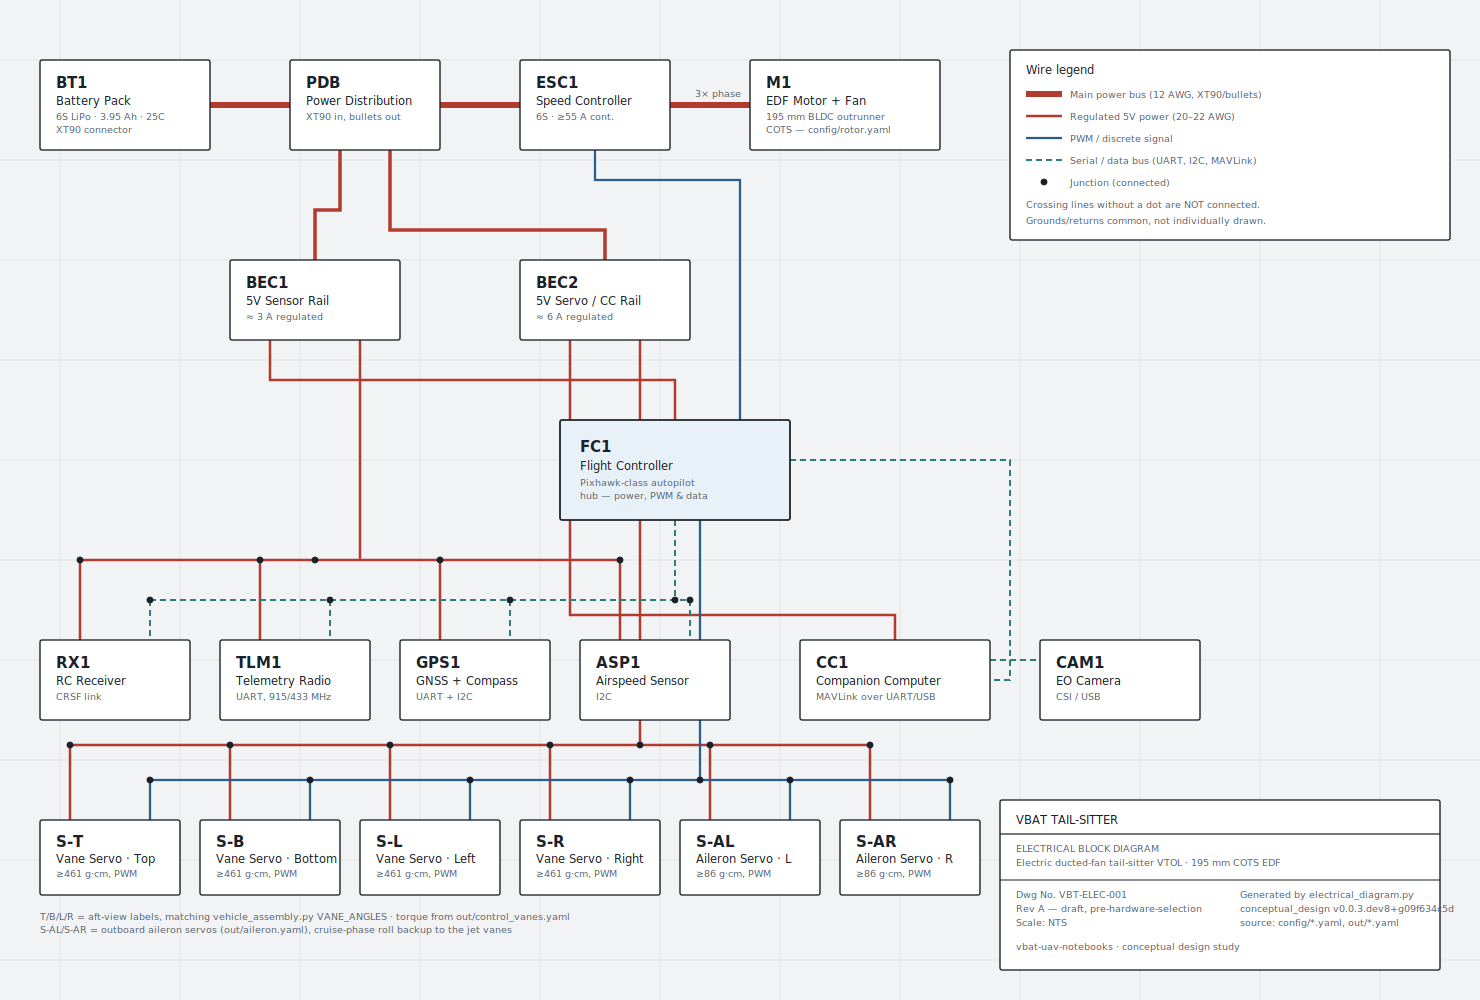

In [4]:
with open(OUT_PATH / "control_vanes.yaml") as f:
    vanes = yaml.safe_load(f)
with open(OUT_PATH / "aileron.yaml") as f:
    ail = yaml.safe_load(f)

svg = render_wiring_svg(
    op, elec, rotor, batt,
    servo_torque_gcm = vanes["servo_torque_req_gcm"],
    aileron_servo_torque_gcm = ail["servo_torque_req_gcm"],
    package_version  = cd.__version__,
)

display(SVG(svg))

---
## 4 — Export

In [5]:
paths = write_wiring_diagram(svg, op, elec, OUT_PATH)
for k, v in paths.items():
    print(f"{k:<5}: {v}")

svg  : D:\Dev\vbat-uav-notebooks\out\wiring_diagram.svg
yaml : D:\Dev\vbat-uav-notebooks\out\electrical.yaml


---
## Open items before this becomes a build drawing

| Item | Status |
|---|---|
| EDF motor / ESC part numbers | Open — no thrust-stand map yet for a specific 195 mm COTS motor/prop combo (2026-07 design review) |
| Flight controller / companion computer models | Open — "Pixhawk-class" / "companion computer" are placeholders matching `config/avionics.yaml`'s 15 W hotel-load budget |
| Single vs. redundant FC power path | Open — this diagram shows one BEC per rail; a flight-critical build may want diode-ORed redundancy |
| Battery cell count | Fixed at 6S in `config/electrical.yaml` — keeps hover current at a buildable 34–35 A on standard hobby components |

Grounds/returns are common and intentionally not drawn individually —
this is a block diagram, not a full schematic. Crossing lines without a
junction dot are **not** connected.